In [39]:
import yfinance as yf
import pandas as pd
import numpy as np

TICKERS = [
    # US Core
    "SPY","IVV","VOO","QQQ","VTI","ITOT","DIA","IWM","IJR","MDY",
    # Styles / Factors
    "VUG","IWF","VTV","IWD","SCHD","VIG","DVY","MTUM","QUAL","USMV","VLUE",
    # Sectors
    "XLK","XLF","XLV","XLY","XLP","XLE","XLI","XLU","XLB","XLRE",
    # International
    "VEA","IEFA","VWO","IEMG","EFA","EEM","EWJ","EWG","EWU","EWQ",
    "INDA","EWZ","FXI","MCHI","EWT","EWY",
    # Bonds
    "BND","AGG","IEF","TLT","SHY","LQD","HYG","JNK","TIP","BIL",
    # Commodities / REITs
    "GLD","IAU","SLV","USO","DBC","VNQ",
]




In [40]:
# Descargar datos históricos
data = yf.download(TICKERS, start="2021-01-01", auto_adjust=False, progress=False)


In [41]:
variables = data.columns.get_level_values(0).unique()
variables


Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [42]:
for v in variables:
    print(v, data[v].shape)


Adj Close (1273, 63)
Close (1273, 63)
High (1273, 63)
Low (1273, 63)
Open (1273, 63)
Volume (1273, 63)


Yahoo Finance proporciona precios de apertura (Open), máximo (High), mínimo (Low) y cierre (Close), el precio ajustado por dividendos y splits (Adj Close), que se utiliza para calcular retornos, y el volumen negociado (Volume), que sirve como medida de liquidez.


In [43]:

#Precios y volumen histórico
adj = data["Adj Close"]
vol = data["Volume"] #cuántas participaciones se han comprado/vendido ese día

# Close = último precio del día
# Adj Close = precio ajustado por dividendos y splits
print("Adj Close shape:", adj.shape)
print("Volume shape:", vol.shape)

# Vista básica
display(adj.head()) 
# Cada columna = un ETF
# Cada fila = un día de mercado
# Cada celda = precio ajustado de ese ETF ese día
display(vol.head())


Adj Close shape: (1273, 63)
Volume shape: (1273, 63)


Ticker,AGG,BIL,BND,DBC,DIA,DVY,EEM,EFA,EWG,EWJ,...,XLB,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,101.754189,78.455879,75.627869,12.721416,276.643799,79.074394,46.271252,62.786312,28.436779,59.164669,...,32.456772,15.711835,26.672201,80.046898,61.501373,58.505486,29.902744,26.242634,104.278328,76.565460
2021-01-05,101.650749,78.447311,75.499054,13.078175,278.034637,79.983948,47.383537,63.436966,28.578251,59.714134,...,33.185577,16.415470,26.791437,80.834320,61.900482,58.505486,29.868935,26.238342,105.035355,77.137001
2021-01-06,101.150780,78.455879,75.164131,13.095576,282.033447,83.146622,46.983109,64.164642,28.834681,60.423122,...,34.543606,16.916300,27.974630,82.761139,60.832981,58.549313,29.725250,26.890972,106.475624,77.924637
2021-01-07,101.047340,78.455879,75.009567,13.156486,284.129059,83.405281,47.428028,64.233124,28.976154,60.299042,...,34.801628,17.164644,28.378195,83.215080,62.472694,58.373947,29.818213,26.538898,107.860443,79.427902
2021-01-08,100.926666,78.447311,74.940865,13.260902,284.623260,82.979721,48.682693,64.832397,29.108788,61.406830,...,34.634136,17.143944,28.359854,83.011269,62.876617,58.663315,30.139393,26.762165,108.377449,81.065643


Ticker,AGG,BIL,BND,DBC,DIA,DVY,EEM,EFA,EWG,EWJ,...,XLB,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,6414100,1588000,7568400,5740000,5106600.0,1151600,48201300.0,26703400,4783800,9211700,...,18266000.0,67717600.0,47086300,16200700,21017200,12992600,4967000,25260600.0,12911800,18120400
2021-01-05,7477900,940300,6452700,2395800,3355200.0,1260400,53358000.0,19748500,5248300,5756200,...,26812000.0,95473400.0,35265400,16004600,12361400,10871900,4432400,16666600.0,11081900,6262400
2021-01-06,10687200,1710800,5933700,3370800,7290300.0,1215900,56418700.0,25426900,4872000,7863500,...,48521400.0,86262800.0,102254900,19500600,27258000,14206600,7383400,35961800.0,17833700,8832000
2021-01-07,6639400,1249400,6196100,2627200,4107900.0,750400,41031300.0,18783700,5665200,8367000,...,18577800.0,51457200.0,64342700,10114900,19652000,13963500,3433700,24758800.0,12407100,6725600
2021-01-08,7335700,1767600,7688800,2920300,3234900.0,715500,76024300.0,25272200,4780100,9557400,...,16988400.0,62744000.0,54266400,11043300,12387600,17960800,3419900,26930600.0,9350600,9283800


In [44]:

# Nulos por ticker (para saber si tienen dias sin datos dentro de cada etf)
nan_ratio = adj.isna().mean().sort_values(ascending=False)
display(nan_ratio.head(15))

# Tickers que han bajado bien (pocos NaNs)
good = nan_ratio[nan_ratio <= 0.05].index.tolist()
print("Tickers con <=5% NaNs:", len(good))


Ticker
DIA     0.000786
EEM     0.000786
EWY     0.000786
EWZ     0.000786
IWM     0.000786
IEFA    0.000786
IJR     0.000786
ITOT    0.000786
LQD     0.000786
XLB     0.000786
XLU     0.000786
SPY     0.000786
VIG     0.000786
SLV     0.000786
QQQ     0.000786
dtype: float64

Tickers con <=5% NaNs: 63


El objetivo de este proyecto es analizar si predicciones aproximadas de ganancias y riesgo diario pueden ayudar a decidir mejor cómo gestionar una cartera de inversión, teniendo en cuenta los costes de compra y venta y la posibilidad de mantener la cartera sin cambios.

Para que la cartera sea realista, se analiza la liquidez de los ETFs mediante el volumen diario negociado en dólares, ya que indica cuánto dinero real se mueve cada día en el mercado. Se eliminan los ETFs con poco volumen porque son más difíciles y caros de comprar o vender. Para ello, se fija un volumen mínimo diario como umbral, que permite trabajar solo con activos suficientemente líquidos.

In [45]:
# Dollar Volume diario = precio ajustado × volumen
dollar_vol = adj * vol
# Añadirlo al dataset principal
data = pd.concat(
    [
        data,
        pd.concat(
            {"Dollar Volume": dollar_vol},
            axis=1
        )
    ],
    axis=1
)


In [46]:
median_dollar_vol = dollar_vol.median()
liquidity_table = median_dollar_vol.sort_values(ascending=False)
display(liquidity_table) #ver de más 


Ticker
SPY     3.249487e+10
QQQ     1.775988e+10
IWM     5.662707e+09
TLT     2.428196e+09
HYG     2.308140e+09
            ...     
EWU     6.058418e+07
DVY     5.964423e+07
VLUE    4.696558e+07
DBC     2.783549e+07
EWQ     1.587127e+07
Length: 63, dtype: float64

In [47]:
threshold = 10_000_000  # 10 millones USD
valid_tickers = median_dollar_vol[median_dollar_vol >= threshold].index
# Contar ETFs antes y después
n_before = len(median_dollar_vol)
n_after = len(valid_tickers)

print("ETFs antes del filtro:", n_before)
print("ETFs después del filtro:", n_after)

# Aplicar filtro al dataset completo
data = data.loc[:, data.columns.get_level_values(1).isin(valid_tickers)]





ETFs antes del filtro: 63
ETFs después del filtro: 63


Todos los ETFs considerados presentan un volumen diario negociado en dólares superior al umbral mínimo establecido, por lo que no fue necesario excluir ninguno por motivos de liquidez.

CALCULAMOS LOS RETORNOS SIMPLES

(hoy − ayer) / ayer


In [48]:
# Retornos
ret_simple = data["Adj Close"].pct_change()
ret_log = np.log(data["Adj Close"]).diff()


In [49]:
data = pd.concat(
    [
        data,
        pd.concat(
            {
                "retorno_simple": ret_simple,
                "retorno_log": ret_log,
            },
            axis=1
        )
    ],
    axis=1
)


In [50]:
# Seleccionamos retornos logarítmicos
returns = data["retorno_log"]
# Estadísticas descriptivas de los retornos
stats = pd.DataFrame({
    "Retorno medio diario": returns.mean(),
    "Desviación típica diaria": returns.std(),
    "Retorno mínimo observado": returns.min(),
    "Percentil 5%": returns.quantile(0.05), #Solo el 5% de los días fueron peores que este valor,los percentiles describen lo que pasa normalmente
    "Percentil 25%": returns.quantile(0.25),
    "Mediana": returns.quantile(0.50),
    "Percentil 75%": returns.quantile(0.75),
    "Percentil 95%": returns.quantile(0.95),
    "Retorno máximo observado": returns.max()
})

# Ordenar por riesgo (volatilidad)
stats = stats.sort_values("Desviación típica diaria", ascending=False)

# Mostrar TODOS los ETFs
display(stats)


,Retorno medio diario,Desviación típica diaria,Retorno mínimo observado,Percentil 5%,Percentil 25%,Mediana,Percentil 75%,Percentil 95%,Retorno máximo observado
Ticker,,,,,,,,,
USO,0.000675,0.020985,-0.123962,-0.033243,-0.011611,0.001500,0.013681,0.031943,0.076115
FXI,-0.000016,0.019870,-0.105267,-0.028956,-0.011254,-0.000725,0.010444,0.030228,0.192612
MCHI,-0.000103,0.019376,-0.114395,-0.028190,-0.010604,-0.000650,0.009866,0.030606,0.190103
SLV,0.001092,0.018947,-0.086604,-0.027584,-0.009559,0.000467,0.011420,0.032034,0.087487
EWZ,0.000339,0.017726,-0.077276,-0.029868,-0.009296,0.000973,0.011436,0.028285,0.093990
...,...,...,...,...,...,...,...,...,...
TIP,0.000037,0.003945,-0.016983,-0.006400,-0.002077,0.000092,0.002261,0.005760,0.017516
AGG,-0.000013,0.003801,-0.016530,-0.006088,-0.002251,0.000000,0.002206,0.006014,0.021243
BND,-0.000015,0.003762,-0.016285,-0.006122,-0.002218,0.000000,0.002226,0.006034,0.020490


In [ ]:
variables = data.columns.get_level_values(0).unique()
variables

Histograma de retornos diarios

Eje horizontal (X)


→ valor del retorno diario:
0 = no cambia; negativo = pierde; positivo = gana


Eje vertical (Y)

→ cuántas veces pasó eso: barras altas = pasó muchas veces;
barras bajas = pasó pocas veces

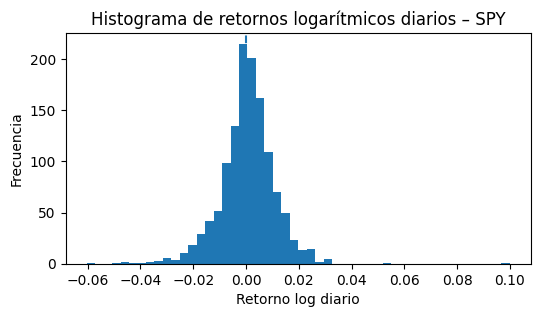

In [51]:
import matplotlib.pyplot as plt

etf = "SPY"   # ETF a analizar

plt.figure(figsize=(6, 3))
plt.hist(returns[etf], bins=50)
plt.title(f"Histograma de retornos logarítmicos diarios – {etf}")
plt.xlabel("Retorno log diario")
plt.ylabel("Frecuencia")
plt.axvline(0, linestyle="--")  # línea en 0 para referencia
plt.show()


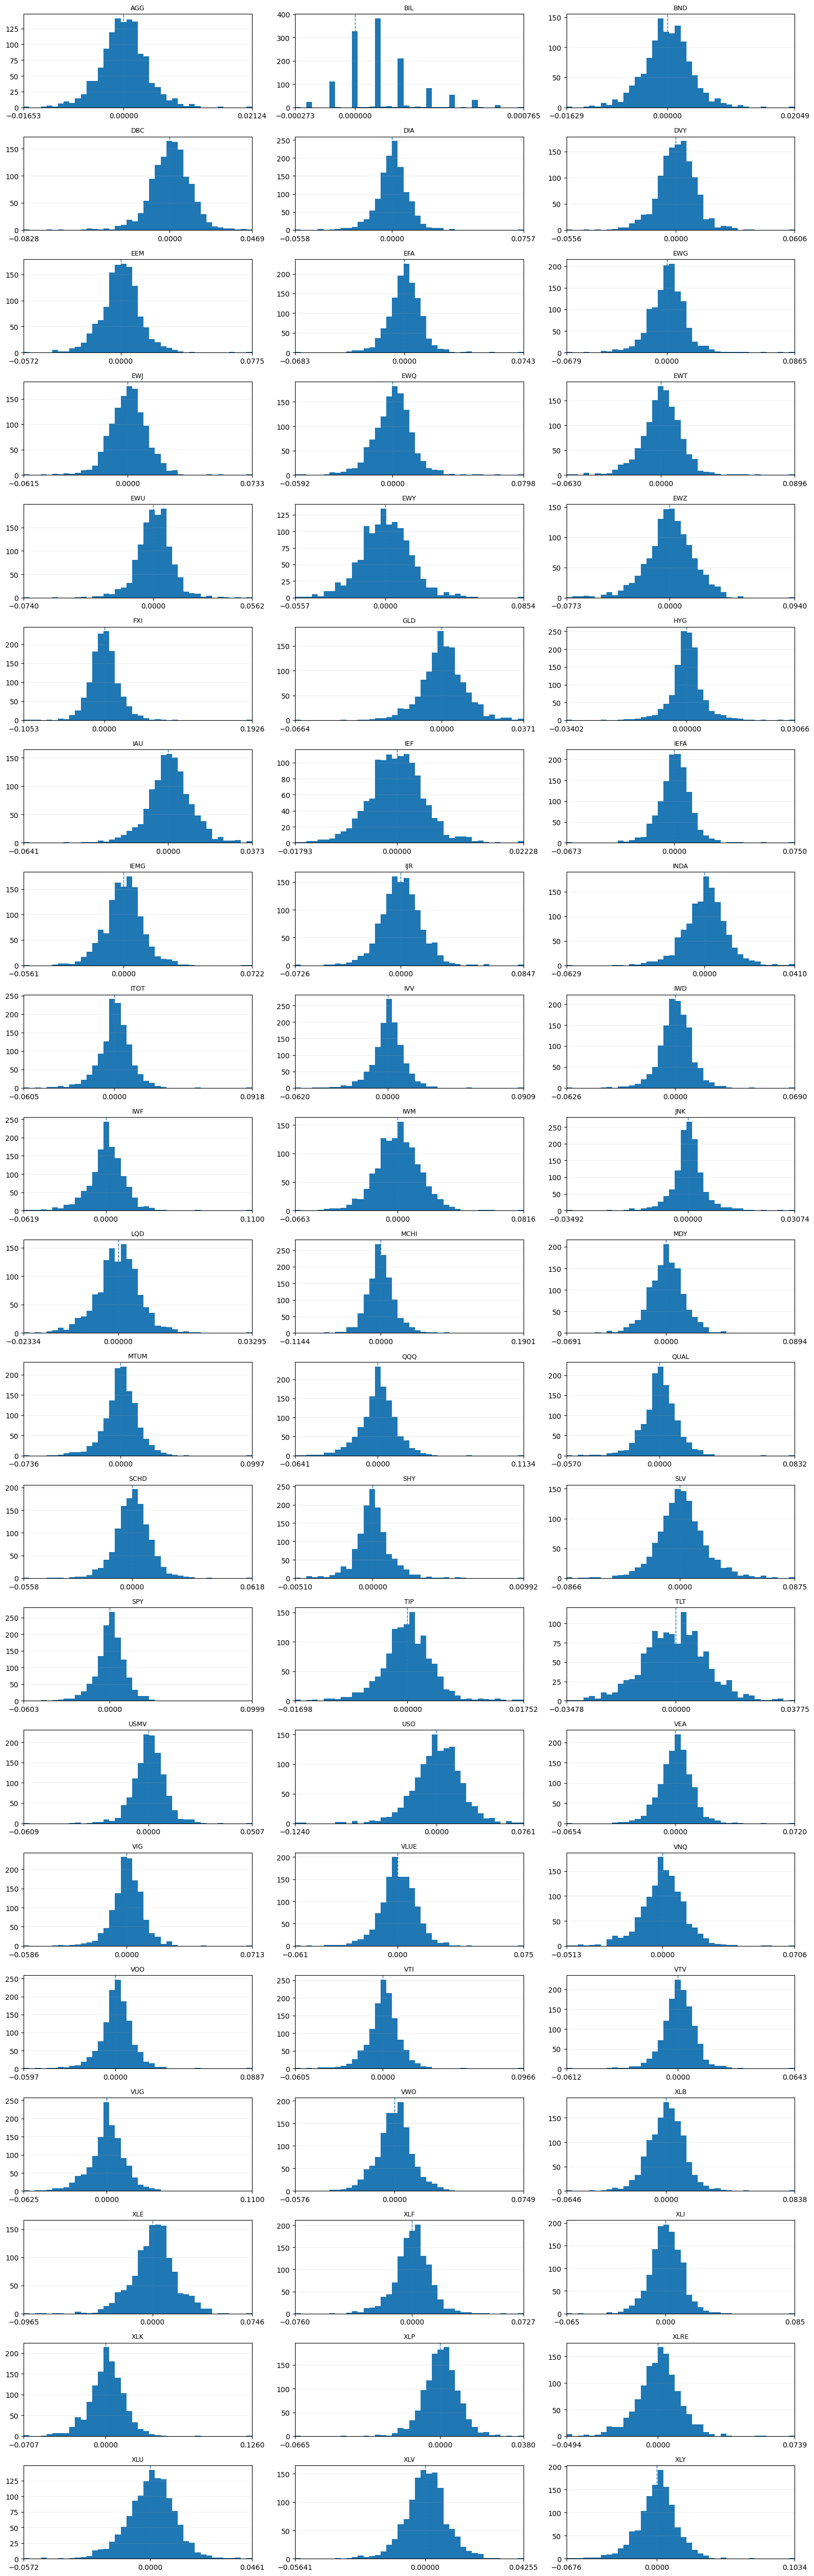

In [52]:
import matplotlib.pyplot as plt
import math
import numpy as np

n_cols = 3
bins = 40

n_etfs = len(returns.columns)
n_rows = math.ceil(n_etfs / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.4 * n_rows))
axes = axes.flatten()

for i, etf in enumerate(returns.columns):
    x = returns[etf].dropna().values

    # rango completo real
    x_min = x.min()
    x_max = x.max()

    # seguridad por si el rango es casi cero (BIL, SHY)
    if np.isclose(x_min, x_max):
        eps = max(abs(x_min), 1e-6)
        x_min -= eps
        x_max += eps

    axes[i].hist(x, bins=bins)
    axes[i].axvline(0, linestyle="--", linewidth=1)

    axes[i].set_title(etf, fontsize=9)
    axes[i].grid(True, alpha=0.2)
    axes[i].set_xlim(x_min, x_max)

    # marcar el 0 si entra
    if x_min < 0 < x_max:
        axes[i].set_xticks([x_min, 0, x_max])
    else:
        axes[i].set_xticks([x_min, x_max])

# borrar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()


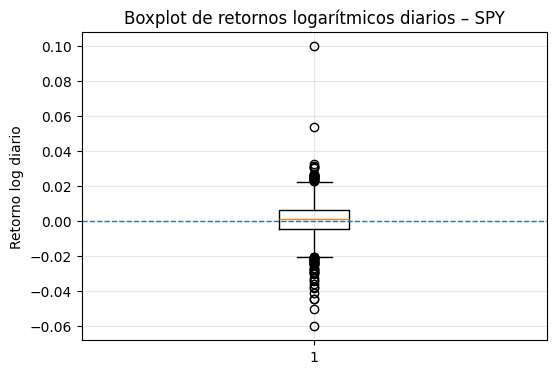

In [53]:
import matplotlib.pyplot as plt

etf = "SPY"   # cambia por el que quieras (SPY, QQQ, USO, etc.)

plt.figure(figsize=(6, 4))

plt.boxplot(returns[etf].dropna(), vert=True)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"Boxplot de retornos logarítmicos diarios – {etf}")
plt.ylabel("Retorno log diario")

plt.grid(True, alpha=0.3)
plt.show()


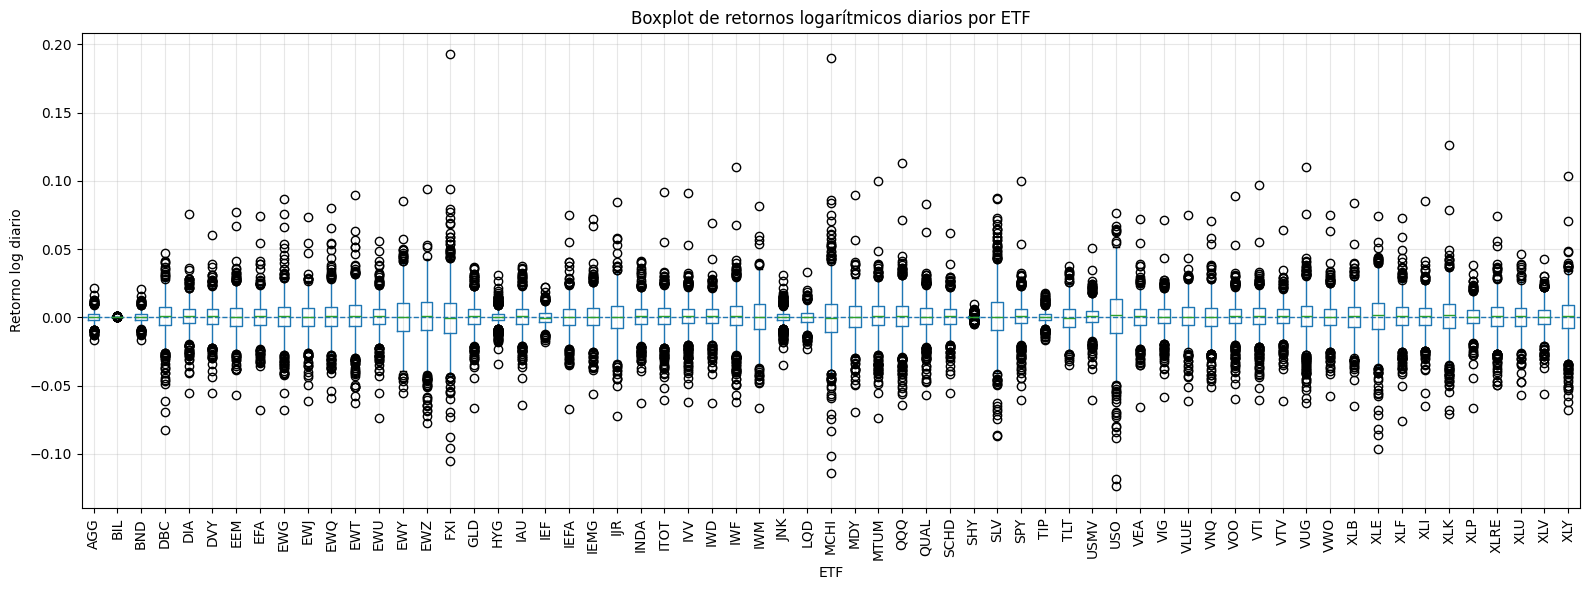

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

returns.boxplot(rot=90)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Boxplot de retornos logarítmicos diarios por ETF")
plt.ylabel("Retorno log diario")
plt.xlabel("ETF")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


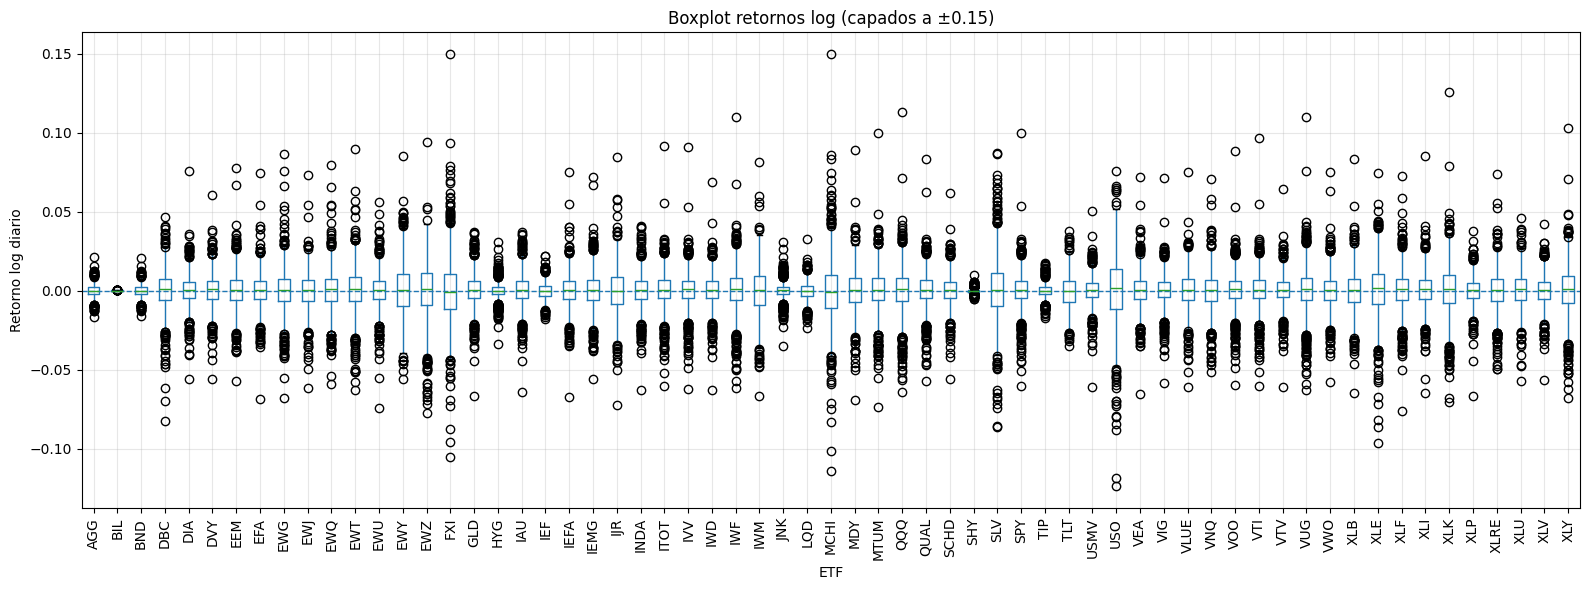

In [64]:
import numpy as np
import matplotlib.pyplot as plt


# Umbral
thr = 0.15

# Capar extremos (winsorizar)
returns = returns.clip(lower=-thr, upper=thr)

# Boxplot igual que antes
plt.figure(figsize=(16, 6))
returns.boxplot(rot=90)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"Boxplot retornos log (capados a ±{thr})")
plt.ylabel("Retorno log diario")
plt.xlabel("ETF")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import os

# Carpeta destino  
out_dir = "../Datos_csv"
os.makedirs(out_dir, exist_ok=True)

# Guardar el dataset
out_path = os.path.join(out_dir, "dataset_inicial.csv")

data.to_csv(out_path, index=True)

print("Guardado en:", out_path)
print("Shape:", data.shape)


Guardado en: ../Datos_csv\dataset_inicial.csv
Shape: (1273, 567)


ANÁLISIS DE COVARIANZAS

Covarianza positiva → se mueven juntos

Covarianza negativa → uno sube cuando otro baja

Covarianza ≈ 0 → no hay relación clara

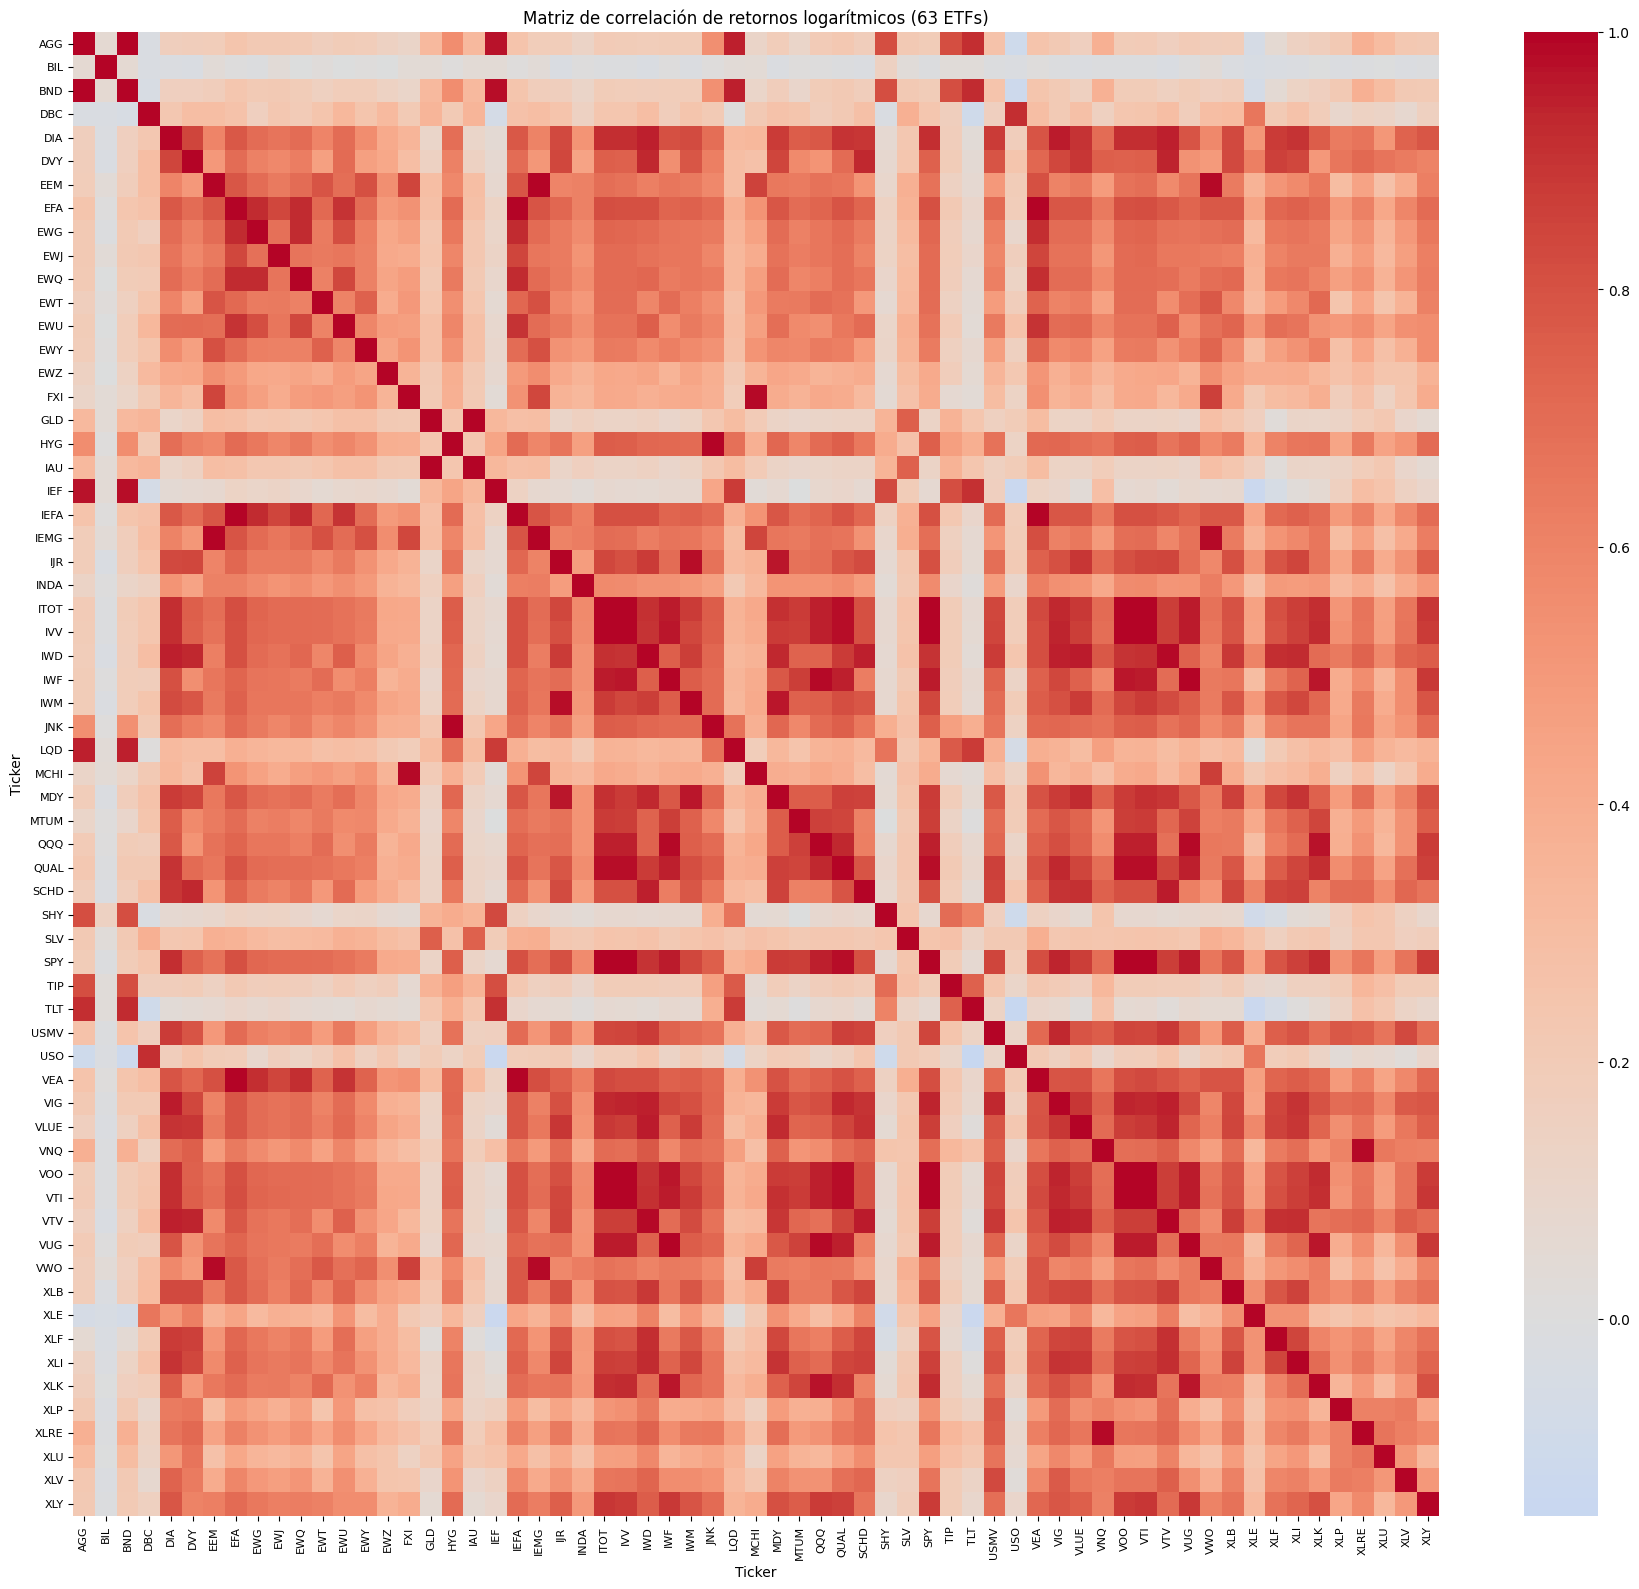

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = returns.corr()

plt.figure(figsize=(18, 16))
ax = sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    xticklabels=corr.columns,
    yticklabels=corr.columns
)

# Rotar etiquetas
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.title("Matriz de correlación de retornos logarítmicos (63 ETFs)")
plt.tight_layout()
plt.show()


In [81]:
import pandas as pd
import numpy as np
import networkx as nx

# Matriz de correlaciones

# Umbral
threshold = 0.95

# Crear grafo, ETFs (nodos) y correlación alta (conexión)
G = nx.Graph()

# Añadir nodos
for etf in corr.columns:
    G.add_node(etf)

print("numero de nodos:", G.number_of_nodes())


# Añadir aristas para correlaciones altas
for i in corr.columns:
    for j in corr.columns:
        if i != j and abs(corr.loc[i, j]) >= threshold:
            G.add_edge(i, j)



numero de nodos: 63


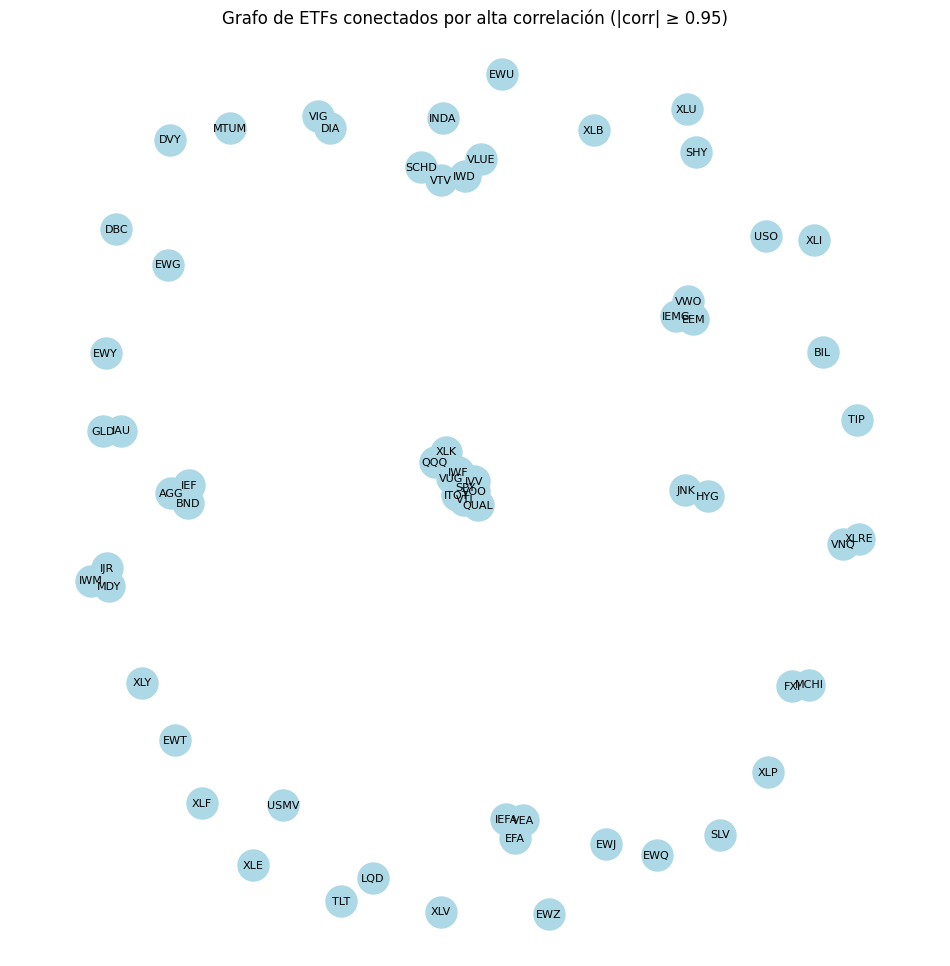

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

# Posición "natural" de los nodos
pos = nx.spring_layout(G, seed=42)

# Dibujar nodos
nx.draw_networkx_nodes(
    G, pos,
    node_size=500,
    node_color="lightblue"
)

# Dibujar aristas (conexiones)
nx.draw_networkx_edges(
    G, pos,
    alpha=0.5
)

# Dibujar etiquetas
nx.draw_networkx_labels(
    G, pos,
    font_size=8
)

plt.title("Grafo de ETFs conectados por alta correlación (|corr| ≥ 0.95)")
plt.axis("off")
plt.show()


El uso de grafos permite identificar grupos de ETFs altamente correlacionados, capturando relaciones directas e indirectas que no se observan al analizar pares de activos de forma aislada.

In [83]:
# Componentes conexos = grupos
groups = list(nx.connected_components(G))

# Convertir a DataFrame para verlos bien
groups_df = pd.DataFrame({
    "Grupo": range(1, len(groups) + 1),
    "ETFs": [sorted(list(g)) for g in groups],
    "Tamaño": [len(g) for g in groups]
})

# Ordenar por tamaño (grupos más grandes primero)
groups_df = groups_df.sort_values("Tamaño", ascending=False)

groups_df


,Grupo,ETFs,Tamaño
19,20,"[ITOT, IVV, IWF, QQQ, QUAL, SPY, VOO, VTI, VUG...",10
20,21,"[IWD, SCHD, VLUE, VTV]",4
17,18,"[IJR, IWM, MDY]",3
6,7,"[EFA, IEFA, VEA]",3
0,1,"[AGG, BND, IEF]",3
5,6,"[EEM, IEMG, VWO]",3
14,15,"[FXI, MCHI]",2
16,17,"[HYG, JNK]",2
15,16,"[GLD, IAU]",2
3,4,"[DIA, VIG]",2


elegir 1 de cada grupo apra elimianr redundancia, ya que si sube 1, suben juntos y si cae 1, caen juntos. elegir el de mayor volumen en dolares? ETFs con comportamientos prácticamente idénticos se consideran redundantes desde el punto de vista del riesgo.

In [84]:
# Dollar Volume medio por ETF
dollar_vol_mean = dollar_vol.mean()
selected_etfs = []

for group in groups:
    group = list(group)
    
    # si el grupo tiene 1 ETF, lo mantenemos
    if len(group) == 1:
        selected_etfs.append(group[0])
    else:
        # elegir el ETF más líquido del grupo
        most_liquid = dollar_vol_mean[group].idxmax()
        selected_etfs.append(most_liquid)

selected_etfs = sorted(selected_etfs)
len(selected_etfs), selected_etfs
# Filtrar dataset original  
data_reduced = data.loc[:, data.columns.get_level_values(1).isin(selected_etfs)]


In [85]:
data_reduced.head()

Adj Close                                                          \
Ticker            BIL        DBC         DIA        DVY        EEM        EFA   
Date                                                                            
2021-01-04  78.455879  12.721416  276.643799  79.074394  46.271252  62.786312   
2021-01-05  78.447311  13.078175  278.034637  79.983948  47.383537  63.436966   
2021-01-06  78.455879  13.095576  282.033447  83.146622  46.983109  64.164642   
2021-01-07  78.455879  13.156486  284.129059  83.405281  47.428028  64.233124   
2021-01-08  78.447311  13.260902  284.623260  82.979721  48.682693  64.832397   

                                                        ... retorno_log  \
Ticker            EWG        EWJ        EWQ        EWT  ...         USO   
Date                                                    ...               
2021-01-04  28.436779  59.164669  28.770750  36.530167  ...         NaN   
2021-01-05  28.578251  59.714134  28.941860  37.311310  ...    0.047053   
2021-01-06  28.834681  60.423122  29.198511  37.290928  ...    0.004996   
2021-01-07  28.976154  60.299042  29.326830  37.949802  ...    0.012238   
2021-01-08  29.108788  61.406830  29.489382  38.221508  ...    0.025730   

                                                                        \
Ticker           VNQ       XLB       XLE       XLF       XLI       XLP   
Date                                                                     
2021-01-04       NaN       NaN       NaN       NaN       NaN       NaN   
2021-01-05  0.001459  0.022206  0.043810  0.004460  0.009789  0.000000   
2021-01-06  0.001700  0.040107  0.030053  0.043216  0.023557  0.000749   
2021-01-07 -0.001943  0.007442  0.014574  0.014323  0.005470 -0.003000   
2021-01-08  0.009677 -0.004824 -0.001207 -0.000647 -0.002452  0.004945   

                                          
Ticker           XLU       XLV       XLY  
Date                                      
2021-01-04       NaN       NaN       NaN  
2021-01-05 -0.000164  0.007233  0.007437  
2021-01-06  0.024569  0.013619  0.010159  
2021-01-07 -0.013179  0.012922  0.019108  
2021-01-08  0.008378  0.004782  0.020410  

[5 rows x 342 columns]

In [ ]:
import pandas as pd

# Matriz de covarianzas
cov = returns.cov()

# Extraer la diagonal, de cada etf consigo mismo, al final es la varianza
var = pd.Series(
    cov.values.diagonal(),
    index=cov.index,
    name="Varianza (riesgo propio)"
)

# Crear DataFrame
var_table = var.to_frame()

# Ordenar de mayor a menor riesgo
var_table = var_table.sort_values("Varianza (riesgo propio)", ascending=False)

var_table.head(63)


,Varianza (riesgo propio)
Ticker,
USO,4.403513e-04
FXI,3.833229e-04
MCHI,3.646885e-04
SLV,3.589986e-04
EWZ,3.142253e-04
...,...
TIP,1.556009e-05
AGG,1.444660e-05
BND,1.415374e-05


Ordnado de más arriesgado a más estable. La varianza individual mide la volatilidad propia de cada ETF, independientemente de su relación con el resto.

Voy a ver si, con predicciones imperfectas y error acotado, puedo tomar mejores decisiones que no hacer nada”